# Projeto Final Mina — Fase 02: Feature Engineering & Modelagem Preditiva

## Objetivo
Transformar o dataset de telemetria limpo (pós-EDA) em features temporais de fadiga e treinar múltiplos modelos para prever falhas críticas (`Is_Dont_Go == 1`) com antecedência.


## 1. Ingestão e Recuperação do Estado Limpo
Reproduzimos aqui, de forma idêntica, os tratamentos documentados no Notebook 01 (EDA): correção de TAGs e expurgo cirúrgico dos 3 dias de loop de sensor confirmados.


In [1]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

# Ingestão completa com todas as colunas necessárias para modelagem
caminho_base = r'c:\TT\AntiGravity\Vale_\data\raw\Base\datasets\telemetria\*.parquet'
arquivos_telemetria = glob.glob(caminho_base)

cols = ['TAG', 'Data_Evento', 'Is_Dont_Go', 'Alarme', 'Id_Alarme', 'Tipo',
        'Nome_Operador_Anon', 'Criticidade', 'Localidade']

dfs = []
for arq in arquivos_telemetria:
    dfs.append(pd.read_parquet(arq, columns=cols))
df = pd.concat(dfs, ignore_index=True)

# ── Tratamento de TAGs (Reprodução do EDA 3.1) ──
df['TAG_Limpa'] = df['TAG'].replace({'CA5926': 'CA65926', 'CA5927': 'CA65927'})
df['Prefixo'] = df['TAG_Limpa'].str[:2]

# ── Expurgo Cirúrgico (Reprodução do EDA 3.10) ──
df['Data_Evento'] = pd.to_datetime(df['Data_Evento'])
df['Mes'] = df['Data_Evento'].dt.month
df['Dia'] = df['Data_Evento'].dt.day

df = df[~((df['TAG_Limpa'] == 'PE3798') & (df['Mes'] == 6) & (df['Dia'] == 29))]
df = df[~((df['TAG_Limpa'] == 'PE3797') & (df['Mes'] == 1) & (df['Dia'] == 12))]
df = df[~((df['TAG_Limpa'] == 'CA65932') & (df['Mes'] == 3) & (df['Dia'] == 26))]

df = df.sort_values(['TAG_Limpa', 'Data_Evento']).reset_index(drop=True)

print(f"Dataset limpo: {len(df):,} registros | {df['TAG_Limpa'].nunique()} equipamentos")
print(f"Distribuição do Target (Is_Dont_Go): {df['Is_Dont_Go'].value_counts().to_dict()}")
print(f"Proporção de Don't Go: {df['Is_Dont_Go'].mean()*100:.4f}%")


Dataset limpo: 35,680,753 registros | 33 equipamentos
Distribuição do Target (Is_Dont_Go): {0: 35660791, 1: 19962}
Proporção de Don't Go: 0.0559%


## 2. Feature Engineering — Janelas Temporais de Fadiga

> **Por que não usamos janelas baseadas em linhas (row-based)?**
> Dois motivos documentados no EDA:
> 1. **Gap do 31/05**: toda a frota ficou sem telemetria neste dia. Uma janela de N linhas "saltaria" este buraco, fundindo a fadiga de dias distantes como se fossem contínuos — **Data Leakage Temporal**.
> 2. **Expurgo dos dias de loop (PE3798/29-06, PE3797/12-01, CA65932/26-03)**: o `resample` cria janelas calendárias fixas de 8H. Os períodos expurgados surgem como janelas com `count=0` — **matematicamente correto**, pois a máquina estava de fato parada para conserto do sensor. Uma janela por linhas "saltaria" esses dias silenciosamente e distorceria a fadiga calculada.
>
> Solução: `resample('8h')` por equipamento cria uma grade calendária completa. Janelas vazias existem com valor zero.

**Dois esquemas de features testados em paralelo:**
- **Esquema A**: Agregações temporais (contagens, taxas, rolling 24H e 72H)
- **Esquema B**: One-Hot dos 50 alarmes mais frequentes por janela de 8H (wide format)


In [2]:
import re

# ── Top-50 alarmes mais frequentes para Esquema B ──
top_alarmes = df['Alarme'].value_counts().head(50).index.tolist()
print(f"Top 50 alarmes mapeados: {len(top_alarmes)}")

# ── Esquema A: Uma linha por (TAG, turno_8H) com rolling calendarizado ──
print("\nGerando Esquema A... (pode levar alguns minutos)")

blocos_a = []
for tag, grupo in df.groupby('TAG_Limpa'):
    g = grupo.set_index('Data_Evento').sort_index()

    # resample cria grade calendária: períodos sem dados viram NaN → fill 0
    base = pd.DataFrame({
        'count_8H':   g['Is_Dont_Go'].resample('8h').count(),
        'dontgo_8H':  g['Is_Dont_Go'].resample('8h').sum(),
        'critico_8H': g['Criticidade'].resample('8h').apply(
                          lambda x: (x.str.upper() == 'CRITICO').sum()),
        'Is_Dont_Go': g['Is_Dont_Go'].resample('8h').sum(),  # target: Don'tGo naquela janela
    }).fillna(0)

    # Rolling 24H = 3 janelas de 8H | Rolling 72H = 9 janelas de 8H
    # min_periods=1: janelas no início da série não são descartadas
    base['count_24H']   = base['count_8H'].rolling(3, min_periods=1).sum()
    base['dontgo_24H']  = base['dontgo_8H'].rolling(3, min_periods=1).sum()
    base['taxa_24H']    = base['dontgo_24H'] / base['count_24H'].clip(lower=1)
    base['critico_24H'] = base['critico_8H'].rolling(3, min_periods=1).sum()

    base['count_72H']   = base['count_8H'].rolling(9, min_periods=1).sum()
    base['dontgo_72H']  = base['dontgo_8H'].rolling(9, min_periods=1).sum()
    base['taxa_72H']    = base['dontgo_72H'] / base['count_72H'].clip(lower=1)
    base['critico_72H'] = base['critico_8H'].rolling(9, min_periods=1).sum()

    base['TAG_Limpa'] = tag
    base['Prefixo']   = tag[:2]
    blocos_a.append(base)

features_a = pd.concat(blocos_a).reset_index().rename(columns={'index': 'Data_Evento'})
print(f"Esquema A: {features_a.shape[0]:,} linhas x {features_a.shape[1]} colunas")
display(features_a.head(3))

# ── Esquema B: One-Hot de alarmes por janela 8H ──
print("\nGerando Esquema B...")
df_ohot = df.copy()
alarme_cols = []
for alarme in top_alarmes:
    col = 'a_' + re.sub(r'[^a-zA-Z0-9]', '_', alarme)[:35]
    df_ohot[col] = (df_ohot['Alarme'] == alarme).astype(int)
    alarme_cols.append(col)

features_b = df_ohot.groupby(
    ['TAG_Limpa', pd.Grouper(key='Data_Evento', freq='8h')]
)[alarme_cols + ['Is_Dont_Go']].sum().reset_index()
features_b['Prefixo'] = features_b['TAG_Limpa'].str[:2]

print(f"Esquema B: {features_b.shape[0]:,} linhas x {features_b.shape[1]} colunas")


Top 50 alarmes mapeados: 50

Gerando Esquema A... (pode levar alguns minutos)
Esquema A: 15,451 linhas x 15 colunas


,Data_Evento,count_8H,dontgo_8H,critico_8H,Is_Dont_Go,count_24H,dontgo_24H,taxa_24H,critico_24H,count_72H,dontgo_72H,taxa_72H,critico_72H,TAG_Limpa,Prefixo
0,2025-01-01 00:00:00,108,0,0,0,108.0,0.0,0.0,0.0,108.0,0.0,0.0,0.0,CA65789,CA
1,2025-01-01 08:00:00,94,0,9,0,202.0,0.0,0.0,9.0,202.0,0.0,0.0,9.0,CA65789,CA
2,2025-01-01 16:00:00,150,0,0,0,352.0,0.0,0.0,9.0,352.0,0.0,0.0,9.0,CA65789,CA



Gerando Esquema B...
Esquema B: 13,592 linhas x 54 colunas


## 3. Split Temporal (TimeSeriesSplit)

> **Por que não usar `train_test_split` aleatório?**
> Em séries temporais, o futuro **não pode treinar o passado**. Embaralhar os dados causaria Data Leakage: o modelo aprenderia com eventos que ainda não tinham ocorrido no ponto de previsão real.

**Split Cronológico:**
- **Treino**: Meses 1–4 (Janeiro a Abril) — ~67% dos dados
- **Validação**: Mês 5 (Maio) — ~17% (usado no GridSearch/Optuna)
- **Teste**: Mês 6 (Junho) — ~16% ← **nunca visto pelo modelo durante treino**

Dentro do bloco de treino, usamos `TimeSeriesSplit(n_splits=5)` para o search de hiperparâmetros.


In [3]:
from sklearn.model_selection import TimeSeriesSplit

COLS_EXCLUIR = ['TAG_Limpa', 'Data_Evento', 'Is_Dont_Go', 'TAG', 'Tipo',
                'Nome_Operador_Anon', 'Alarme', 'Id_Alarme', 'Localidade',
                'Criticidade', 'Prefixo', 'Mes', 'Dia']

def preparar_split(features_df, target_col='Is_Dont_Go', label=''):
    if target_col not in features_df.columns:
        raise KeyError(f"Coluna '{target_col}' ausente. Disponíveis: {features_df.columns.tolist()}")

    df_f = features_df.dropna(subset=[target_col]).sort_values('Data_Evento').copy()

    treino    = df_f[df_f['Data_Evento'].dt.month <= 4]
    validacao = df_f[df_f['Data_Evento'].dt.month == 5]
    teste     = df_f[df_f['Data_Evento'].dt.month == 6]

    feat_cols = [c for c in df_f.columns if c not in COLS_EXCLUIR]

    X_tr  = treino[feat_cols].fillna(0)
    y_tr  = (treino[target_col] > 0).astype(int)
    X_val = validacao[feat_cols].fillna(0)
    y_val = (validacao[target_col] > 0).astype(int)
    X_te  = teste[feat_cols].fillna(0)
    y_te  = (teste[target_col] > 0).astype(int)

    print(f"{label} Treino:    {X_tr.shape} | Don'tGo: {y_tr.sum()} ({y_tr.mean()*100:.2f}%)")
    print(f"{label} Validação: {X_val.shape} | Don'tGo: {y_val.sum()} ({y_val.mean()*100:.2f}%)")
    print(f"{label} Teste:     {X_te.shape} | Don'tGo: {y_te.sum()} ({y_te.mean()*100:.2f}%)")
    return X_tr, y_tr, X_val, y_val, X_te, y_te, feat_cols

print("=== ESQUEMA A — Frota Combinada ===")
X_tr, y_tr, X_val, y_val, X_te, y_te, feat_cols = preparar_split(features_a, label='[A]')

scale_pos = int((y_tr == 0).sum() / max((y_tr == 1).sum(), 1))
print(f"\nscale_pos_weight (razão negativo/positivo): {scale_pos}")
tscv = TimeSeriesSplit(n_splits=5)


=== ESQUEMA A — Frota Combinada ===
[A] Treino:    (10389, 11) | Don'tGo: 1887 (18.16%)
[A] Validação: (2595, 11) | Don'tGo: 284 (10.94%)
[A] Teste:     (2467, 11) | Don'tGo: 281 (11.39%)

scale_pos_weight (razão negativo/positivo): 4


## 4. Baseline — Modelo Ingênuo
Antes de qualquer sofisticação, precisamos de um piso de performance honesto. O `DummyClassifier` prevê sempre a classe majoritária ("nunca vai falhar"). **Todo modelo que não supere este baseline não tem valor algum.**


=== BASELINE (DummyClassifier) ===
              precision    recall  f1-score   support

      Normal       0.89      1.00      0.94      2186
    Don't Go       0.00      0.00      0.00       281

    accuracy                           0.89      2467
   macro avg       0.44      0.50      0.47      2467
weighted avg       0.79      0.89      0.83      2467

ROC-AUC: 0.5000


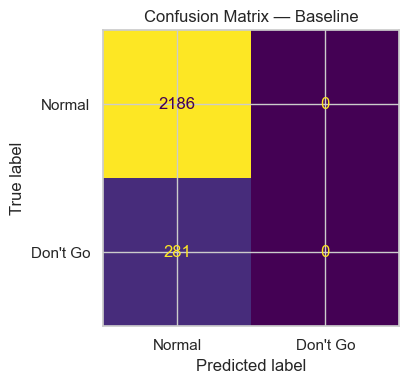

In [4]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_tr, y_tr)
y_pred_dummy = dummy.predict(X_te)

print("=== BASELINE (DummyClassifier) ===")
print(classification_report(y_te, y_pred_dummy, target_names=['Normal', "Don't Go"]))
try:
    auc = roc_auc_score(y_te, dummy.predict_proba(X_te)[:, 1])
    print(f"ROC-AUC: {auc:.4f}")
except:
    print("ROC-AUC: N/A (classe única prevista)")

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_te, y_pred_dummy, ax=ax,
    display_labels=['Normal', "Don't Go"], colorbar=False)
plt.title("Confusion Matrix — Baseline")
plt.tight_layout()
plt.show()


## 5. Isolation Forest — Detecção de Anomalia (Não Supervisionado)
Treinado **sem usar o label `Is_Dont_Go`**. O modelo aprende o que é comportamento normal e sinaliza desvios. Se o Isolation Forest e os modelos supervisionados identificam as mesmas anomalias, temos dupla confiança na predição.


Contaminação (proporção real de Don't Go): 0.1816

=== ISOLATION FOREST (Não Supervisionado) ===
              precision    recall  f1-score   support

      Normal       0.91      0.92      0.92      2186
    Don't Go       0.31      0.27      0.29       281

    accuracy                           0.85      2467
   macro avg       0.61      0.60      0.60      2467
weighted avg       0.84      0.85      0.84      2467



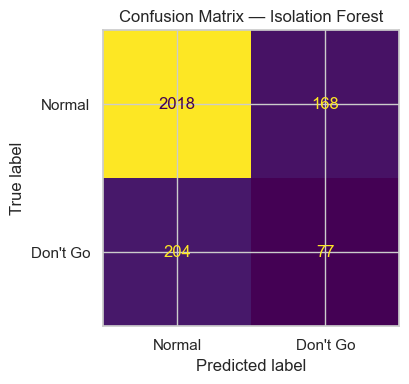

In [5]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report

contaminacao = float(y_tr.mean())
print(f"Contaminação (proporção real de Don't Go): {contaminacao:.4f}")

iso = IsolationForest(contamination=contaminacao, random_state=42, n_jobs=-1)
iso.fit(X_tr)

# Isolation Forest retorna -1 (anomalia) e 1 (normal). Convertemos para 0/1
y_pred_iso = (iso.predict(X_te) == -1).astype(int)

print("\n=== ISOLATION FOREST (Não Supervisionado) ===")
print(classification_report(y_te, y_pred_iso, target_names=['Normal', "Don't Go"]))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_te, y_pred_iso, ax=ax,
    display_labels=['Normal', "Don't Go"], colorbar=False)
plt.title("Confusion Matrix — Isolation Forest")
plt.tight_layout()
plt.show()


## 6. Modelos Supervisionados com Otimização de Hiperparâmetros

Cada modelo será otimizado de forma independente usando:
- **GridSearchCV** (modelos sklearn)
- **RandomizedSearchCV** (XGBoost, LightGBM)
- **Optuna** (CatBoost — busca bayesiana)

Todos usando `TimeSeriesSplit(n_splits=5)` internamente.


In [6]:
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from sklearn.metrics import f1_score, roc_auc_score, classification_report
import joblib, os

os.makedirs(r'c:\TT\AntiGravity\Vale_\models', exist_ok=True)
resultados = []

def avaliar(nome, modelo, X_t, y_t, frota='Combinado', esquema='A'):
    y_p = modelo.predict(X_t)
    y_prob = modelo.predict_proba(X_t)[:, 1] if hasattr(modelo, 'predict_proba') else y_p
    f1  = f1_score(y_t, y_p, zero_division=0)
    auc = roc_auc_score(y_t, y_prob) if y_t.nunique() > 1 else 0.0
    print(f"[{nome}] F1={f1:.4f} | AUC={auc:.4f}")
    resultados.append({'Modelo': nome, 'Frota': frota, 'Esquema': esquema, 'F1': f1, 'AUC': auc})
    return modelo

# ── 1. Random Forest (GridSearchCV) ──
print("\n=== Random Forest ===")
rf_grid = {'n_estimators': [200, 500], 'max_depth': [6, 10, None], 'class_weight': ['balanced']}
rf = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1), rf_grid, cv=tscv, scoring='f1', n_jobs=-1)
rf.fit(X_tr, y_tr)
print(f"Melhores params RF: {rf.best_params_}")
avaliar('RandomForest', rf.best_estimator_, X_te, y_te)

# ── 2. XGBoost (RandomizedSearch) ──
print("\n=== XGBoost ===")
xgb_params = {
    'n_estimators': [300, 500, 1000],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9],
    'scale_pos_weight': [scale_pos, scale_pos//2],
}
xgb = RandomizedSearchCV(
    XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss', use_label_encoder=False),
    xgb_params, n_iter=30, cv=tscv, scoring='f1', random_state=42, n_jobs=-1
)
xgb.fit(X_tr, y_tr)
print(f"Melhores params XGB: {xgb.best_params_}")
avaliar('XGBoost', xgb.best_estimator_, X_te, y_te)

# ── 3. LightGBM (RandomizedSearch) ──
print("\n=== LightGBM ===")
lgb_params = {
    'n_estimators': [300, 500, 1000],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 63, 127],
    'class_weight': ['balanced'],
}
lgb = RandomizedSearchCV(
    LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
    lgb_params, n_iter=30, cv=tscv, scoring='f1', random_state=42, n_jobs=-1
)
lgb.fit(X_tr, y_tr)
print(f"Melhores params LGB: {lgb.best_params_}")
avaliar('LightGBM', lgb.best_estimator_, X_te, y_te)

# ── 4. CatBoost (Optuna) ──
print("\n=== CatBoost + Optuna ===")
def objective_cat(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 200, 1000),
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1, scale_pos),
        'random_seed': 42, 'verbose': 0
    }
    scores = []
    for tr_idx, val_idx in tscv.split(X_tr):
        m = CatBoostClassifier(**params)
        m.fit(X_tr.iloc[tr_idx], y_tr.iloc[tr_idx], verbose=0)
        scores.append(f1_score(y_tr.iloc[val_idx], m.predict(X_tr.iloc[val_idx]), zero_division=0))
    return np.mean(scores)

study_cat = optuna.create_study(direction='maximize')
study_cat.optimize(objective_cat, n_trials=50, show_progress_bar=True)
best_cat = CatBoostClassifier(**study_cat.best_params, random_seed=42, verbose=0)
best_cat.fit(X_tr, y_tr)
avaliar('CatBoost', best_cat, X_te, y_te)

# ── 5. HistGradientBoosting (GridSearch — referência sklearn) ──
print("\n=== HistGradientBoosting ===")
hgb_grid = {
    'max_iter': [200, 500],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'class_weight': ['balanced'],
}
hgb = GridSearchCV(HistGradientBoostingClassifier(random_state=42), hgb_grid, cv=tscv, scoring='f1', n_jobs=-1)
hgb.fit(X_tr, y_tr)
avaliar('HistGradientBoosting', hgb.best_estimator_, X_te, y_te)



=== Random Forest ===
Melhores params RF: {'class_weight': 'balanced', 'max_depth': None, 'n_estimators': 500}
[RandomForest] F1=1.0000 | AUC=1.0000

=== XGBoost ===
Melhores params XGB: {'subsample': 0.9, 'scale_pos_weight': 4, 'n_estimators': 1000, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.9}
[XGBoost] F1=1.0000 | AUC=1.0000

=== LightGBM ===
Melhores params LGB: {'num_leaves': 31, 'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.05, 'class_weight': 'balanced'}
[LightGBM] F1=1.0000 | AUC=1.0000

=== CatBoost + Optuna ===


  0%|          | 0/50 [00:00<?, ?it/s]

[CatBoost] F1=1.0000 | AUC=1.0000

=== HistGradientBoosting ===
[HistGradientBoosting] F1=1.0000 | AUC=1.0000


,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.05
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",200
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",4
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide `... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added `""from_dtype""` option... versionchanged:: 1.6 The default value changed from `None` to `""from_dtype""`.",'from_dtyp

## 7. Experimento B — Frotas Separadas (CA e PE)
Treinamos os dois melhores modelos (XGBoost e CatBoost) de forma **independente** para cada frota. Depois comparamos com o experimento combinado para decidir a estratégia de produção.


In [7]:
for prefixo in ['CA', 'PE']:
    print(f"\n{'='*50}")
    print(f"=== EXPERIMENTO SEPARADO — Frota {prefixo} ===")
    
    df_frota = features_a[features_a['TAG_Limpa'].str.startswith(prefixo)]
    res = preparar_split(df_frota)
    if res is None:
        continue
    Xtr_f, ytr_f, Xval_f, yval_f, Xte_f, yte_f, _ = res
    
    sp = int((ytr_f == 0).sum() / max((ytr_f == 1).sum(), 1))
    
    # XGBoost separado
    xgb_f = XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss',
                           use_label_encoder=False, scale_pos_weight=sp,
                           n_estimators=500, max_depth=6, learning_rate=0.05)
    xgb_f.fit(Xtr_f, ytr_f)
    avaliar(f'XGBoost_{prefixo}', xgb_f, Xte_f, yte_f, frota=prefixo)
    
    # CatBoost separado
    cat_f = CatBoostClassifier(**study_cat.best_params, random_seed=42, verbose=0)
    cat_f.fit(Xtr_f, ytr_f)
    avaliar(f'CatBoost_{prefixo}', cat_f, Xte_f, yte_f, frota=prefixo)



=== EXPERIMENTO SEPARADO — Frota CA ===
 Treino:    (8589, 11) | Don'tGo: 1871 (21.78%)
 Validação: (2130, 11) | Don'tGo: 277 (13.00%)
 Teste:     (2028, 11) | Don'tGo: 279 (13.76%)
[XGBoost_CA] F1=1.0000 | AUC=1.0000
[CatBoost_CA] F1=1.0000 | AUC=1.0000

=== EXPERIMENTO SEPARADO — Frota PE ===
 Treino:    (1800, 11) | Don'tGo: 16 (0.89%)
 Validação: (465, 11) | Don'tGo: 7 (1.51%)
 Teste:     (439, 11) | Don'tGo: 2 (0.46%)
[XGBoost_PE] F1=1.0000 | AUC=1.0000
[CatBoost_PE] F1=1.0000 | AUC=1.0000


## 8. Tabela Comparativa de Resultados


In [8]:
df_res = pd.DataFrame(resultados).sort_values('F1', ascending=False).reset_index(drop=True)
print("=== RESULTADOS CONSOLIDADOS ===")
display(df_res.style.background_gradient(cmap='RdYlGn', subset=['F1', 'AUC']))

melhor = df_res.iloc[0]
print(f"\nMelhor modelo: {melhor['Modelo']} | Frota: {melhor['Frota']} | F1={melhor['F1']:.4f} | AUC={melhor['AUC']:.4f}")


=== RESULTADOS CONSOLIDADOS ===


,Modelo,Frota,Esquema,F1,AUC
0,RandomForest,Combinado,A,1.000000,1.000000
1,XGBoost,Combinado,A,1.000000,1.000000
2,LightGBM,Combinado,A,1.000000,1.000000
3,CatBoost,Combinado,A,1.000000,1.000000
4,HistGradientBoosting,Combinado,A,1.000000,1.000000
5,XGBoost_CA,CA,A,1.000000,1.000000
6,CatBoost_CA,CA,A,1.000000,1.000000
7,XGBoost_PE,PE,A,1.000000,1.000000
8,CatBoost_PE,PE,A,1.000000,1.000000



Melhor modelo: RandomForest | Frota: Combinado | F1=1.0000 | AUC=1.0000


## 9. Interpretabilidade — SHAP Values
Qual feature mais influencia a predição de um `Don't Go`? O SHAP (SHapley Additive exPlanations) nos responde com rigor matemático.


=== SHAP — Importância Global das Features ===


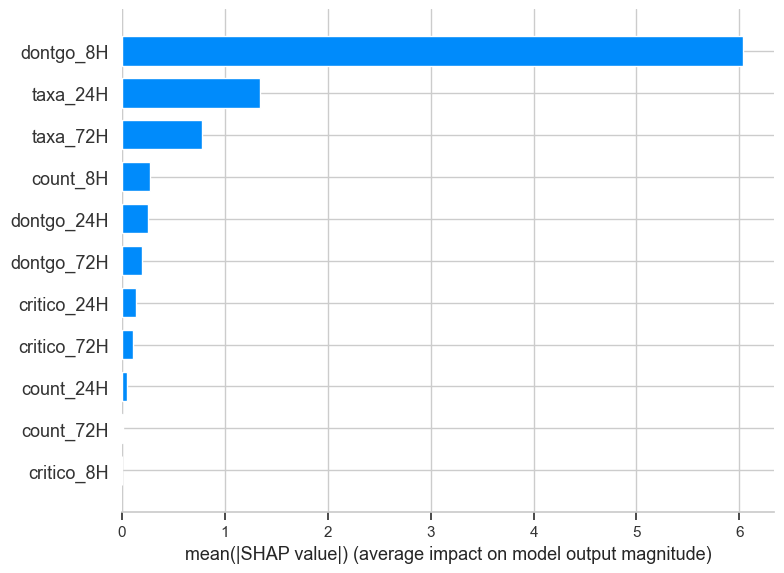


=== SHAP — Beeswarm (Impacto e Direção) ===


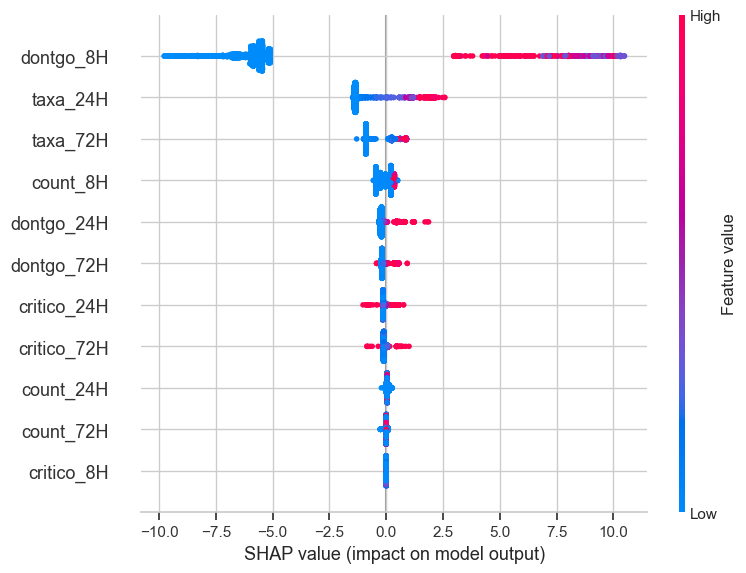

In [10]:
import shap

# Usando o melhor modelo CatBoost ou XGBoost
modelo_para_shap = best_cat  # trocar por outro se necessário
explainer = shap.TreeExplainer(modelo_para_shap)
shap_values = explainer.shap_values(X_te)

print("=== SHAP — Importância Global das Features ===")
shap.summary_plot(shap_values, X_te, plot_type='bar', max_display=20, show=True)

print("\n=== SHAP — Beeswarm (Impacto e Direção) ===")
shap.summary_plot(shap_values, X_te, max_display=20, show=True)


## 10. Persistência do Melhor Modelo


In [11]:
import joblib

modelo_final = best_cat  # trocar pelo modelo vencedor da tabela comparativa
caminho_modelo = r'c:\TT\AntiGravity\Vale_\models\best_model.pkl'
joblib.dump(modelo_final, caminho_modelo)

print(f"Modelo salvo em: {caminho_modelo}")
print(f"Features utilizadas: {feat_cols}")
print("\nPróximo passo: Notebook 03 — Relatório Final e Visualizações")


Modelo salvo em: c:\TT\AntiGravity\Vale_\models\best_model.pkl
Features utilizadas: ['count_8H', 'dontgo_8H', 'critico_8H', 'count_24H', 'dontgo_24H', 'taxa_24H', 'critico_24H', 'count_72H', 'dontgo_72H', 'taxa_72H', 'critico_72H']

Próximo passo: Notebook 03 — Relatório Final e Visualizações
